# A complete Guide to End-to-End Machine Learning Project.
* In this Notebook, we are going to Build an End-to-End Machine Learning Project.
* This notebook will help you how to think while working on End-to-End machine Leanring Project.
* This Notebook will help you to Analyze details from business point of view rather then just modeling.
* Let's say you are working as a data scientist in Real Estate Company.
* Main steps we will go through

# Overviews
**1. Look at the big picture.<br>
2. Get the data.<br>
3. Discover and visualize the data to gain insights.<br>
4. Prepare the data for Machine Learning algorithms.<br>
5. Select a model and train it.<br>
6. Fine-tune your model.<br>
7. Test your model on Test Dataset.**

## 1. Look at the Big Picture

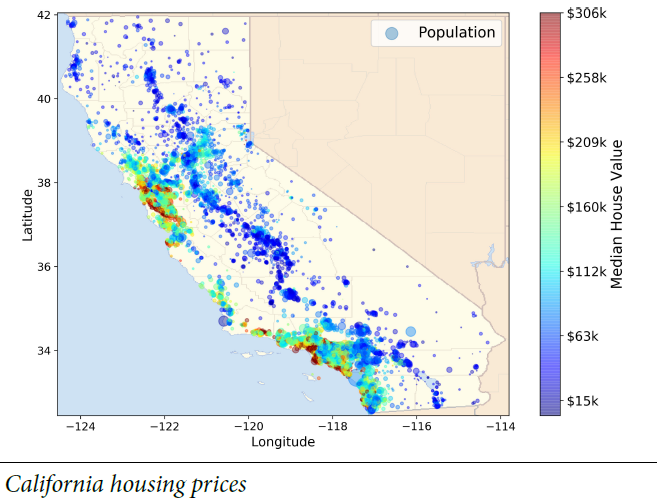

## TASK: As a Data scientist your task is to build a model of housing prices in California using the California census data.

* This data has metrics such as the population, median income, median housing price, and so on for each block group in California.
* Block groups are the smallest geographical unit for which the US Census Bureau publishes sample data.
* We will just call them “districts” for short.
* Your model should learn from this data and be able to predict the median housing price in any district, given all the other metrics.

# Frame the Problem

* First, ask your Boss. What is the **Business objective** of this Model?. How does the company expect to use and benefit from this model?
* Building the Model is not only your end Goal

* Answering the above questions will help you decide what algorithms you will select, what performance measure you will use to evaluate your model, and how much effort you should spend tweaking it.

* Your boss answers that your model’s output (a prediction of a district’s median housing price) will be fed to another Machine Learning system along with many other signals.
* This downstream system will determine whether it is worth investing in a given area or not. **Getting this right is critical, as it directly affects revenue.**

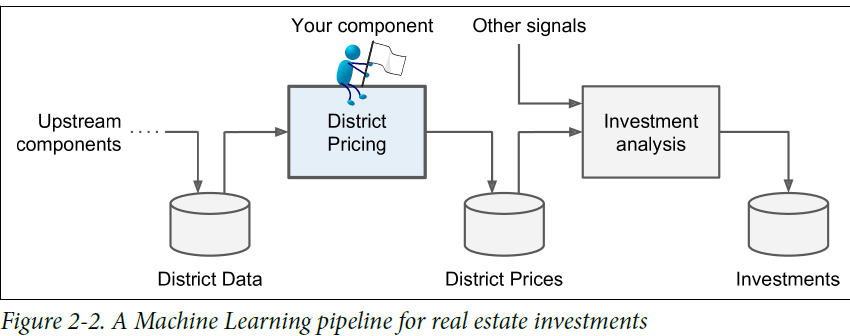

* This task seems to be a Multiple Regression Problem.
* Next, we have to Select a Perfromance Measure.
* A typical performance measure for regression problems is the `Root Mean Square Error (RMSE).`

# 2. Get the Data

In [1]:
# import liraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('C:\\Users\\Ranjan Singh\\OneDrive\\Desktop\\ML_PROJECTS\\california-housing-prices.csv\\housing.csv')

Let's look into the data

In [3]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Inference:
1. There are total 20,640 instances in the dataset. <br>
2. `total_bedrooms` attribute has only 20,433 null values, meaning that 207 districts are missing in this feature.<br>
3. All attributes/columns are numerical, except the `ocean_proximity`.

In [5]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


* Another quick way to get a feel of the type of data you are dealing with is to plot a histogram for each numerical attribute/columns.
* You can call the hist() method on the whole dataset, and it will plot a histogram for each numerical attribute.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

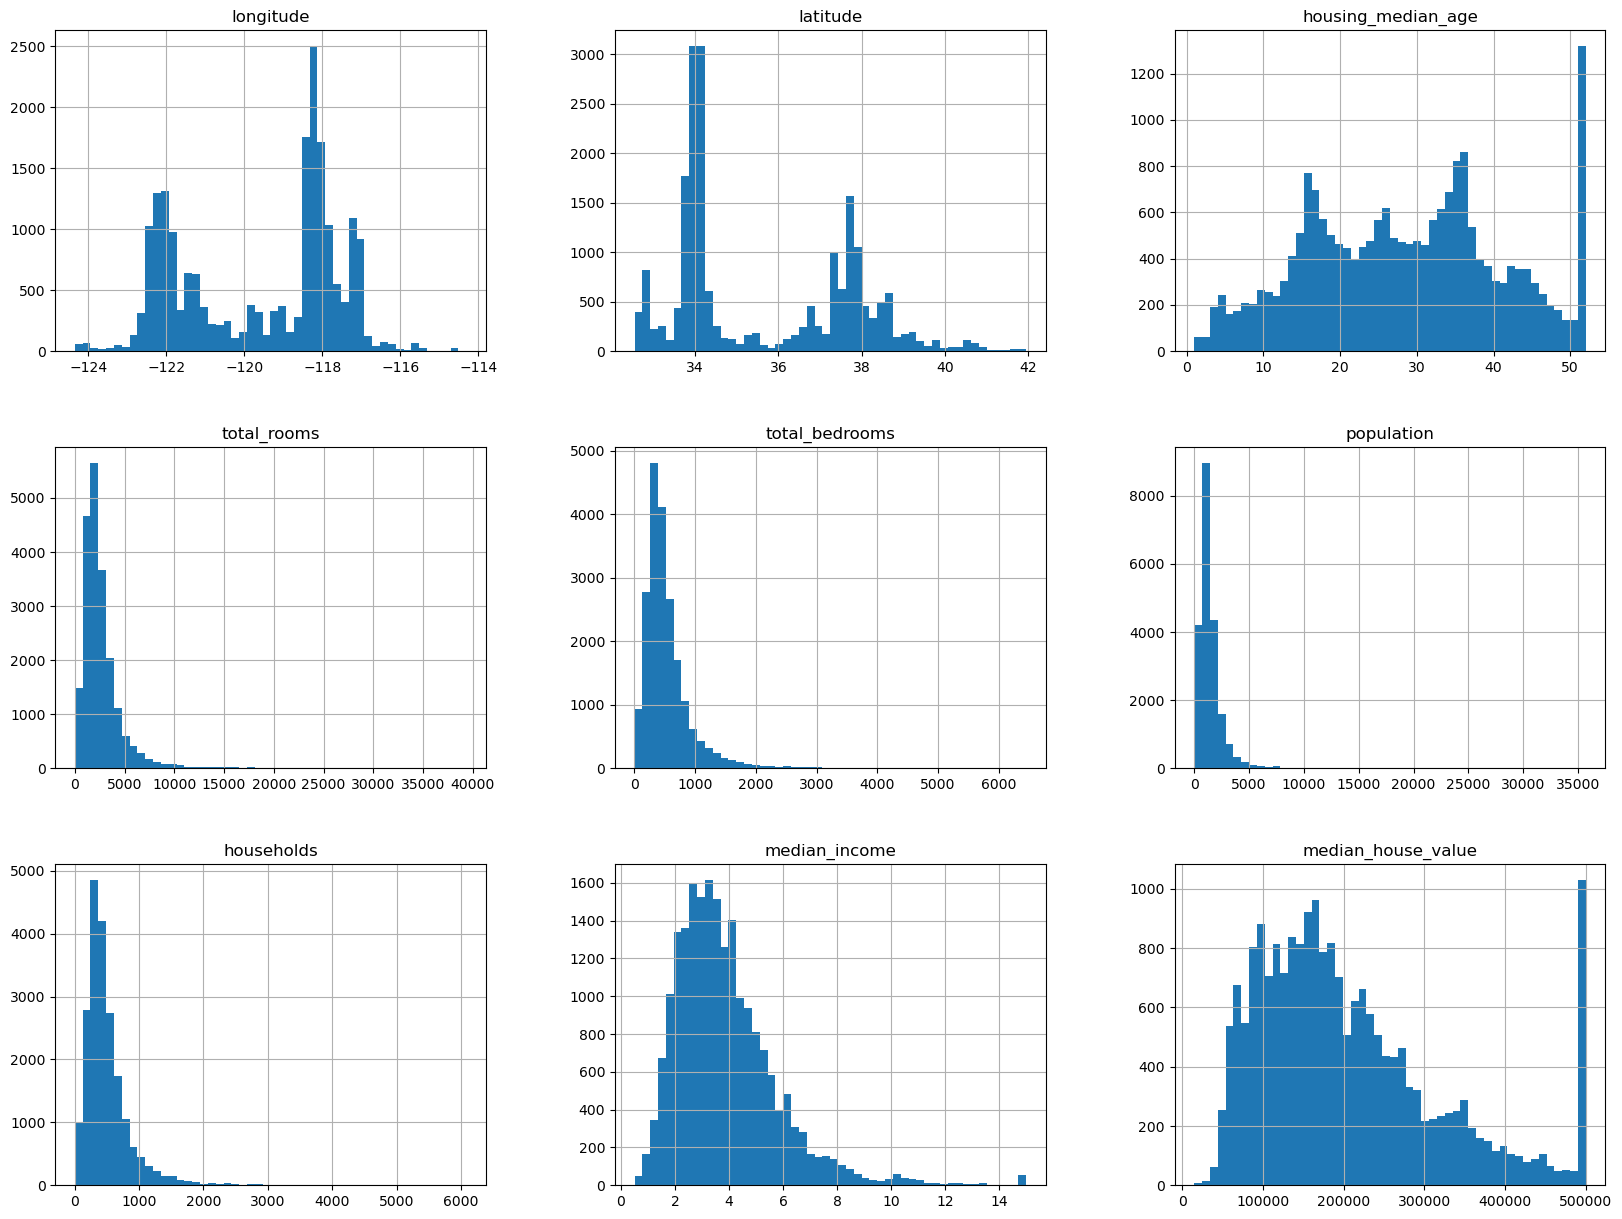

In [7]:
df.hist(bins=50, figsize=(20,15))

### Inference made from these histograms

1. First, the `median income` attribute does not look like it is expressed in `US dollars (USD)`. After checking with the team that collected the data, you are told that the data has been scaled and capped at 15 (actually 15.0001) for higher median incomes, and at 0.5 (actually 0.4999) for lower median incomes. The numbers represent roughly tens of thousands of dollars (e.g., 3 actually means about $30,000).
  * Working with preprocessed attributes is common in Machine Learning, Get the Data and it is not necessarily a problem, **but you should try to understand how the data was computed.**

2. The `housing median age` and the `median house value` were also capped. The later may be a serious problem since it is your target attribute (your labels). Your Machine Learning algorithms may learn that prices never go beyond that limit. You need to check with your client team (the team that will use your system’s output) to see if this is a problem or not. If they tell you that they need precise predictions even beyond  
$500,000, then you have mainly two options: <br>
> a.  Collect proper labels for the districts whose labels were capped.<br>
> b.  Remove those districts from the training set (and also from the test set, since your system should not be evaluated poorly if it predicts values beyond $500,000).


3. These attributes have very different scales. We will discuss this later in this notebook when we explore **feature scaling.**

4. Finally, many histograms are `tail heavy`: they extend much farther to the right of the median than to the left. This may make it a bit harder for some Machine Learning algorithms to detect patterns. We will try transforming these attributes later on to have more bell-shaped distributions.

**NOTE: Before doing anything with data. Let's create a test set and never look at it to avoid bais.**

In [8]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=None)

### Points to consider while doing train_test_split

- So far we have considered purely random sampling methods. This is generally fine if your dataset is large enough (especially relative to the number of attributes), but if it is not, you run the risk of introducing a significant sampling bias.
- When a survey company decides to call 1,000 people to ask them a few questions, they don’t just pick 1,000 people randomly in a phone book. They try to ensure that these 1,000 people are representative of the whole population.
- For example, the US population is composed of 51.3% female and 48.7% male, so a well-conducted survey in the US would try to maintain this ratio in the sample: 513 female and 487 male. **This is called stratified sampling: the population is divided into homogeneous subgroups called strata, and the right number of instances is sampled from each stratum to guarantee that the test set is representative of the overall population.**

#### Business insights
- Suppose you chatted with experts who told you that the median income is a very important attribute to predict median housing prices.
- You may want to ensure that the test set is representative of the various categories of incomes in the whole dataset.
- Since the median income is a continuous numerical attribute, you first need to create an income category attribute.
- Let’s look at the median income histogram more closely (back in Figure of histograms): most median income values are clustered around 1.5 to 6 (i.e., 15,000– 60,000), but some median incomes go far beyond 6.
- It is important to have a sufficient number of instances in your dataset for each stratum, or else the estimate of the stratum’s importance may be biased. This means that you should not have too many strata, and each stratum should be large enough.
- The following code uses the pd.cut() function to create an income category attribute with 5 categories (labeled from 1 to 5): category 1 ranges from 0 to 1.5 (i.e., less than $15,000), category 2 from 1.5 to 3, and so on:

In [9]:
# Bin values into discrete intervals.
df["income_cat"] = pd.cut(df["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5]) #cut the median income across bins and give labels to each bin

<Axes: >

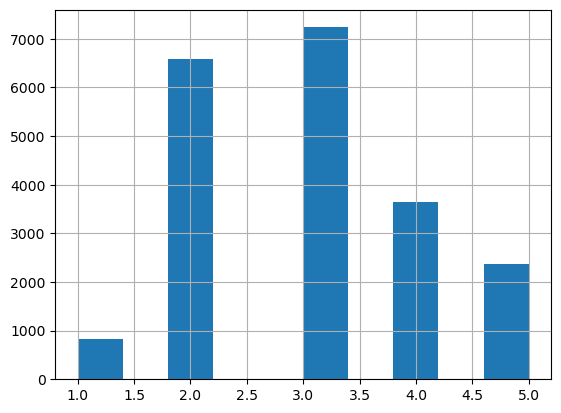

In [10]:
df["income_cat"].hist()

Now, Let's do `stratified sampling` based on the income category. For this you can use `Scikit-Learn’s StratifiedShuffleSplit` class:

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # Provides train/test indices to split data in train/test sets.
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [12]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [13]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

You can see the proportion of each class is same in train and test set and it is also same in df(you can check).

* Now you should remove the income_cat attribute so the data is back to its original state:

In [14]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

* We spent quite a bit of time on test set generation for a good reason: this is an often neglected but critical part of a Machine Learning project.
* Moreover, many of these ideas will be useful later when we discuss cross-validation.
* Now it’s time to move on to the next stage: exploring the data.

# More to Add